## Problem1
$
\begin{align}
    I=\int_0^1\frac{x^{-1/2}}{e^x+1}~dx,~w(x)=x^{-1/2}
\end{align}
$
### (a)
$
\begin{align}
    \int_0^1w(x)~dx&=\int_0^1x^{-1/2}~dx=\bigg[2x^{1/2}\bigg]_0^1=2\\
    \therefore p(x)&=\frac{w(x)}{\int_0^1w(x')~dx'}\frac{x^{-1/2}}{2}=\frac{1}{2\sqrt{x}}
\end{align}
$
Let us define the random number $z$ as $0\le z \le 1$. Then, probability distribution is $q(z)=1$. To transform $z$ to another random number $x$ which follows $p(x)$,
$
\begin{align}
    p(x)dx&=q(x)dz\\
    &=dz\\
    z&=\int_0^{x(z)}p(x')dx'=\int_0^x\frac{dx'}{2\sqrt{x'}}=\bigg[x'^{1/2}\bigg]_0^x=\sqrt{x}\\
    \therefore x&=z^2
\end{align}
$


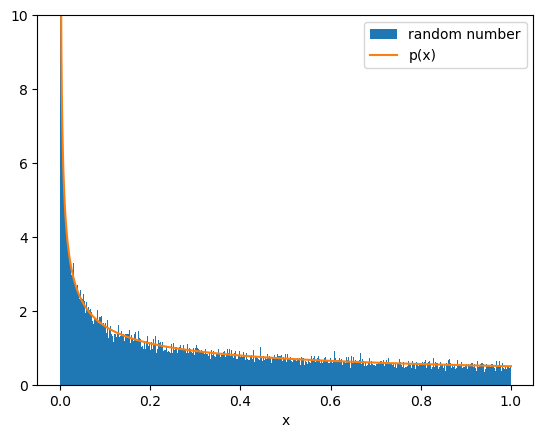

In [1]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt


def p(x):
    # probability distribution
    return 1/(2*np.sqrt(x))


z = nr.rand(100000) # uniform
x = z**2 # p(x)

X = np.linspace(0.0001, 1, 1000)
pdf = p(X)

plt.hist(x, bins=1000, density=True, label='random number')
plt.plot(X, pdf, label='p(x)')
plt.ylim((0, 10))
plt.xlabel('x')
plt.legend()
plt.show()

In [2]:
# (b)

def f_w(x):
    # f(x)/w(x)
    return 1/(np.exp(x) + 1)


N = 1000000 
repeat = 10
I = 0

for i in range(repeat):
    z = nr.rand(N)
    x = z**2
    yr = f_w(x)
    I += yr.sum()/N*2

I /= repeat
print(I)

0.8389346959069603


## Problem 2

In [3]:
# (a)


def Energy(spins, J=1):
    # Calculating energy for open boundary condition

    E = np.sum(spins[:, 1:]*spins[:, :-1]) + np.sum(spins[1:, :]*spins[:-1, :])
    
    return -J*E

In [4]:
# (b)

N = 20 # NxN array
N2 = N*N

spins = np.ones((N2), dtype=int)
spins[:int(N2/2)] = -1
nr.shuffle(spins)
spins = spins.reshape(N, N)
print(spins)
print(spins.mean())


[[ 1 -1 -1  1  1  1 -1  1  1 -1  1  1 -1  1 -1 -1  1  1 -1  1]
 [-1 -1  1  1 -1 -1  1  1 -1  1  1 -1 -1 -1 -1 -1 -1  1  1 -1]
 [ 1  1 -1 -1  1  1 -1 -1 -1  1 -1 -1 -1  1 -1  1  1 -1 -1 -1]
 [-1  1  1 -1  1  1  1 -1 -1 -1 -1 -1  1 -1  1 -1 -1 -1 -1  1]
 [ 1 -1  1 -1 -1  1  1 -1  1 -1 -1  1  1  1  1 -1 -1  1 -1 -1]
 [ 1 -1  1  1  1 -1  1 -1 -1 -1  1 -1  1  1  1 -1 -1  1 -1 -1]
 [ 1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1 -1  1 -1 -1 -1]
 [-1  1 -1  1  1  1  1 -1 -1 -1  1  1 -1 -1 -1 -1 -1  1 -1  1]
 [-1 -1  1 -1  1  1 -1  1  1 -1  1 -1 -1  1 -1  1 -1 -1  1  1]
 [-1  1 -1  1 -1 -1  1 -1 -1  1  1 -1  1 -1  1  1  1  1 -1 -1]
 [ 1  1 -1  1 -1 -1 -1  1  1 -1 -1  1  1  1  1 -1 -1 -1 -1 -1]
 [-1 -1  1  1  1  1  1  1 -1 -1 -1 -1  1 -1  1  1 -1  1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1 -1  1 -1 -1  1 -1  1  1 -1  1  1  1 -1]
 [ 1  1  1 -1 -1  1  1 -1 -1 -1  1  1  1 -1  1 -1  1  1  1 -1]
 [-1 -1 -1  1 -1 -1  1  1 -1 -1 -1 -1  1 -1 -1 -1  1  1  1 -1]
 [-1 -1 -1  1  1 -1  1 -1  1 -1 -1  1 -1  1  1 -1 -1  1

## Problem 3

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


L = 101


def Brownian(p, L=L):
    # current position: [p[0], p[1]]

    step = {0:[0, 1], # Right
            1:[0, -1], # Left
            2:[1, 0], # Up
            3:[-1, 0] # Down
            }

    direction = nr.randint(0, 4)

    i_next = p[0] + step[direction][0]
    j_next = p[1] + step[direction][1]

    # Checking out of bound
    if (0 <= i_next < L) and (0 <= j_next < L):
        # Inside of bound: update
        p[0] = i_next
        p[1] = j_next

    else:
        print(f"stopped at {p}")
    

def update_brownian(frame, p, im):
    Brownian(p) # p is mutable
    im.set_offsets([[p[0], p[1]]])
    ax.set_title(frame)

    return [im]


grid = np.zeros((L, L), dtype=int)
# Inital point
p = [50, 50]

fig = plt.figure()
ax = plt.gca()
im = ax.scatter(p[0], p[1])
ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_aspect('equal')
ax.set_title(0)

ani = FuncAnimation(fig, update_brownian, fargs=(p, im), frames=np.arange(10**2))
plt.close(fig)
#ani.save("Brownian_motion.mp4", writer="ffmpeg")
HTML(ani.to_jshtml())

## Problem 4

In [ ]:
# (a)

L = 101


def Brownian_DLA(p, frame, L=L):
    # current position: [p[0], p[1]]

    step = {0:[0, 1], # Right
            1:[0, -1], # Left
            2:[1, 0], # Up
            3:[-1, 0] # Down
            }

    direction = nr.randint(0, 4)

    i_next = p[0] + step[direction][0]
    j_next = p[1] + step[direction][1]

    # Checking out of bound
    if (0 <= i_next < L) and (0 <= j_next < L):
        # Inside of bound: Update
        p[0] = i_next
        p[1] = j_next

        return True

    else:
        return False